# Speaker-Change Detector Parameter Tuning

Tunes `InstantChangeDetector`'s four parameters (`speaker-k`, `std-floor`,
`speaker-min-window`, `speaker-max-window`) against synthetic multi-speaker
sessions built from single-speaker clips.

Each section below is a separate, runnable cell so you can debug/inspect
one stage (e.g. "did the session builder alternate speakers correctly?")
without re-running the whole pipeline. Re-run cells top to bottom on first
use; after that, cells are safe to re-run individually as long as their
inputs (variables from earlier cells) still exist in memory.

See `MANUAL.md` for the dataset layout this notebook expects.

In [28]:
import os
import sys
import json
from pathlib import Path

import numpy as np

PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), Path.cwd().parent)
     if (candidate / "data").is_dir() and (candidate / "models").is_dir()),
    Path.cwd(),
)
EVAL_DIR = PROJECT_ROOT / "eval"
sys.path.insert(0, str(EVAL_DIR))

sys.path.insert(0, os.path.abspath("."))
from importlib import reload
import speaker_tuning_lib
reload(speaker_tuning_lib)
from speaker_tuning_lib import (
    discover_speaker_clips,
    build_synthetic_session,
    build_session_suite,
    EmbeddingExtractor,
    embed_session,
    embed_and_cache_suite,
    load_cached_embeddings,
    InstantChangeDetector,
    run_detector_on_session,
    prf_beta,
    evaluate_params,
    grid_search,
    train_val_split,
    results_table,
    save_results_json,
    SAMPLE_RATE,
)

print("Imports OK")

Imports OK


## 1. Configuration

Edit these paths for your machine, then run the cell.

In [29]:
DATASET_DIR = str(PROJECT_ROOT / "data/speaker_tuning/speakers")  # <speaker_id>/*.wav
EMBEDDING_MODEL = str(PROJECT_ROOT / "models/wespeaker_en_voxceleb_CAM++.onnx")
OUT_DIR = str(PROJECT_ROOT / "results")
NUM_THREADS = 4
PROVIDER = "cpu"        # or "cuda"
SEED = 0
VAL_FRACTION = 0.3
BETA = 1.5              # >1 weights recall higher than precision

os.makedirs(OUT_DIR, exist_ok=True)

## 2. Discover the dataset

Debug checkpoint: confirm the loader found the speakers and clip counts
you expect before doing anything expensive. If a speaker looks wrong here
(e.g. 1 clip only), check the layout against MANUAL.md.

In [30]:
speaker_clips = discover_speaker_clips(DATASET_DIR)

print(f"Found {len(speaker_clips)} speakers")
for spk, clips in speaker_clips.items():
    print(f"  {spk}: {len(clips)} clips")

if len(speaker_clips) < 6:
    print("\nWARNING: fewer than 6 speakers. See MANUAL.md recommended dataset size.")

Found 10 speakers
  addiction_male: 8 clips
  duolingo_male: 6 clips
  lila_rose_e235_woman_a: 8 clips
  lila_rose_e235_woman_b: 7 clips
  man_child_male: 8 clips
  podcast_male: 5 clips
  podcast_woman: 5 clips
  ted_woman: 7 clips
  turn_23_male: 9 clips
  yale_male: 8 clips


## 3. Sanity-check one synthetic session

Build a single small session and print it out turn by turn: which speaker,
which source clip, and the ground-truth `true_change` flag. This is the
easiest place to catch a bug in the interleaving logic (e.g. two
consecutive turns from the same speaker, which should never happen).

In [31]:
demo_session = build_synthetic_session(
    speaker_clips, name="demo", num_speakers=min(4, len(speaker_clips)),
    gap_seconds=0.5, turns_per_speaker=6, seed=SEED,
)

for i, seg in enumerate(demo_session.segments):
    dur = len(seg.audio) / SAMPLE_RATE
    print(f"segment {i:2d}  speaker={seg.speaker_id:<12} dur={dur:5.2f}s  true_change={seg.true_change}")

# Sanity check: sessions are now built as RUNS (1-3 consecutive same-speaker
# segments before a switch), not strict alternation -- so same-speaker
# consecutive segments are expected and desirable (they let the detector's
# window build a baseline). What should NEVER happen is a switch back to
# the immediately preceding speaker with a run of length 0 in between --
# i.e. true_change should never be True for two segments in a row from a
# speaker that also appeared as segment i-2 with no distinct run. This is
# just checking the run-building logic didn't produce a same-speaker
# "change" (a contradiction: true_change=True but same speaker as prev).
bad = [i for i in range(1, len(demo_session.segments))
       if demo_session.segments[i].true_change
       and demo_session.segments[i].speaker_id == demo_session.segments[i-1].speaker_id]
assert not bad, f"true_change=True but same speaker as previous at indices {bad} -- bug"

n_changes = sum(seg.true_change for seg in demo_session.segments)
n_segments = len(demo_session.segments)
print(f"\nOK: {n_changes}/{n_segments-1} segment boundaries are true speaker changes "
      f"({100*n_changes/(n_segments-1):.0f}%). Should be well under 100% now -- "
      "runs of same-speaker segments exist for the detector to calibrate against.")


segment  0  speaker=lila_rose_e235_woman_a dur= 5.45s  true_change=False
segment  1  speaker=lila_rose_e235_woman_a dur=11.53s  true_change=False
segment  2  speaker=addiction_male dur= 5.60s  true_change=True
segment  3  speaker=addiction_male dur= 7.02s  true_change=False
segment  4  speaker=podcast_woman dur= 5.97s  true_change=True
segment  5  speaker=podcast_woman dur= 3.17s  true_change=False
segment  6  speaker=podcast_woman dur= 4.58s  true_change=False
segment  7  speaker=yale_male    dur= 3.98s  true_change=True
segment  8  speaker=lila_rose_e235_woman_a dur= 5.72s  true_change=True
segment  9  speaker=lila_rose_e235_woman_a dur= 3.97s  true_change=False
segment 10  speaker=addiction_male dur= 8.14s  true_change=True
segment 11  speaker=addiction_male dur= 8.93s  true_change=False
segment 12  speaker=addiction_male dur= 5.21s  true_change=False
segment 13  speaker=lila_rose_e235_woman_a dur= 4.02s  true_change=True
segment 14  speaker=addiction_male dur= 5.35s  true_change=Tr

## 4. Build the full session suite

This is what the CLI script uses by default: varies speaker count (2/4/6)
and gap length (0.5s / 0.2s / 0.0s). See `MANUAL.md` for what each config
is meant to stress.

In [32]:
sessions = build_session_suite(speaker_clips, seed=SEED)

print(f"Built {len(sessions)} sessions:")
for s in sessions:
    n_speakers = len(set(seg.speaker_id for seg in s.segments))
    n_changes = sum(seg.true_change for seg in s.segments)
    print(f"  {s.name:<20} segments={len(s.segments):3d}  speakers={n_speakers}  "
          f"true_changes={n_changes}  gap={s.gap_seconds}s")

Built 19 sessions:
  spk2_gap0.5_run1-3_0 segments= 12  speakers=2  true_changes=4  gap=0.5s
  spk2_gap0.5_run1-3_1 segments= 12  speakers=2  true_changes=5  gap=0.5s
  spk2_gap0.5_run1-3_2 segments= 12  speakers=2  true_changes=5  gap=0.5s
  spk4_gap0.5_run1-3_0 segments= 20  speakers=4  true_changes=9  gap=0.5s
  spk4_gap0.5_run1-3_1 segments= 20  speakers=4  true_changes=8  gap=0.5s
  spk4_gap0.5_run1-3_2 segments= 20  speakers=4  true_changes=12  gap=0.5s
  spk6_gap0.5_run1-3_0 segments= 24  speakers=6  true_changes=11  gap=0.5s
  spk6_gap0.5_run1-3_1 segments= 24  speakers=5  true_changes=10  gap=0.5s
  spk6_gap0.5_run1-3_2 segments= 24  speakers=5  true_changes=12  gap=0.5s
  spk2_gap0.2_run1-3_0 segments= 12  speakers=2  true_changes=5  gap=0.2s
  spk2_gap0.2_run1-3_1 segments= 12  speakers=2  true_changes=5  gap=0.2s
  spk4_gap0.2_run1-3_0 segments= 20  speakers=4  true_changes=7  gap=0.2s
  spk4_gap0.2_run1-3_1 segments= 20  speakers=4  true_changes=8  gap=0.2s
  spk2_gap0.0_r

## 5. Load the embedding extractor and test it on one clip

Debug checkpoint: confirms the sherpa-onnx model loads and produces a
vector of the expected dimension before you commit to embedding the whole
suite. If this cell fails, check `EMBEDDING_MODEL` path and that
`sherpa-onnx` is installed (`pip install sherpa-onnx`).

In [33]:
extractor = EmbeddingExtractor(EMBEDDING_MODEL, num_threads=NUM_THREADS, provider=PROVIDER)
print(f"Embedding dimension: {extractor.dim}")

sample_clip = demo_session.segments[0].audio
sample_emb = extractor.compute(sample_clip)
print(f"Sample embedding shape: {sample_emb.shape}, norm: {np.linalg.norm(sample_emb):.4f}")
assert sample_emb.shape == (extractor.dim,)
assert abs(np.linalg.norm(sample_emb) - 1.0) < 1e-3, "embedding should be L2-normalized"
print("OK")

Embedding dimension: 512
Sample embedding shape: (512,), norm: 1.0000
OK


## 6. Embed the demo session and inspect same/different-speaker similarity

This is the same sanity check you ran manually for `embeddings.json`
earlier, but automated over a whole synthetic session. Look at whether
same-speaker pairs cluster above different-speaker pairs -- if the gap is
tiny or reversed for your dataset, the detector has little to work with no
matter how you tune it, and that's worth knowing before a big grid search.

In [34]:
demo_embeddings = embed_session(demo_session, extractor)

same_spk_sims, diff_spk_sims = [], []
for i in range(len(demo_embeddings)):
    for j in range(i + 1, len(demo_embeddings)):
        sim = float(np.dot(demo_embeddings[i], demo_embeddings[j]))
        if demo_session.segments[i].speaker_id == demo_session.segments[j].speaker_id:
            same_spk_sims.append(sim)
        else:
            diff_spk_sims.append(sim)

print(f"Same-speaker pairs:      n={len(same_spk_sims):3d}  mean={np.mean(same_spk_sims):.3f}  std={np.std(same_spk_sims):.3f}")
print(f"Different-speaker pairs: n={len(diff_spk_sims):3d}  mean={np.mean(diff_spk_sims):.3f}  std={np.std(diff_spk_sims):.3f}")
gap = np.mean(same_spk_sims) - np.mean(diff_spk_sims)
print(f"Gap: {gap:.3f}  ({'looks usable' if gap > 0.1 else 'WARNING: narrow gap, expect a hard tuning problem'})")

Same-speaker pairs:      n= 67  mean=0.646  std=0.216
Different-speaker pairs: n=209  mean=0.424  std=0.145
Gap: 0.221  (looks usable)


## 7. Test the detector on the demo session with default parameters

Runs `InstantChangeDetector` segment-by-segment and prints a side-by-side
of true vs. predicted changes -- the fastest way to see exactly *which*
turns the detector gets wrong before trusting an aggregate metric.

In [35]:
DEFAULT_K = 2.5
DEFAULT_STD_FLOOR = 0.05
DEFAULT_MIN_WINDOW = 3
DEFAULT_MAX_WINDOW = 20
DEFAULT_MIN_ACTIVE_SECONDS = 0.0   # e.g. 1.5 to require ~1.5s of audio before detecting

detector = InstantChangeDetector(k=DEFAULT_K, std_floor=DEFAULT_STD_FLOOR,
                                  min_window=DEFAULT_MIN_WINDOW, max_window=DEFAULT_MAX_WINDOW,
                                  min_active_seconds=DEFAULT_MIN_ACTIVE_SECONDS)

durations = [len(seg.audio) / SAMPLE_RATE for seg in demo_session.segments]

print(f"{'seg':>3} {'speaker':<12} {'dur':>5} {'true':>6} {'pred':>6} {'match':>6}")
detector.process(demo_embeddings[0], duration_sec=durations[0])  # seed, not scored
print(f"{0:>3} {demo_session.segments[0].speaker_id:<12} {durations[0]:>5.1f} {'--':>6} {'--':>6} {'seed':>6}")
for i in range(1, len(demo_embeddings)):
    pred = detector.process(demo_embeddings[i], duration_sec=durations[i])
    true = demo_session.segments[i].true_change
    mark = "OK" if pred == true else "MISS"
    print(f"{i:>3} {demo_session.segments[i].speaker_id:<12} {durations[i]:>5.1f} "
          f"{str(true):>6} {str(pred):>6} {mark:>6}")


seg speaker        dur   true   pred  match
  0 lila_rose_e235_woman_a   5.4     --     --   seed
  1 lila_rose_e235_woman_a  11.5  False  False     OK
  2 addiction_male   5.6   True  False   MISS
  3 addiction_male   7.0  False   True   MISS
  4 podcast_woman   6.0   True  False   MISS
  5 podcast_woman   3.2  False  False     OK
  6 podcast_woman   4.6  False  False     OK
  7 yale_male      4.0   True   True     OK
  8 lila_rose_e235_woman_a   5.7   True  False   MISS
  9 lila_rose_e235_woman_a   4.0  False  False     OK
 10 addiction_male   8.1   True   True     OK
 11 addiction_male   8.9  False  False     OK
 12 addiction_male   5.2  False  False     OK
 13 lila_rose_e235_woman_a   4.0   True   True     OK
 14 addiction_male   5.4   True  False   MISS
 15 addiction_male   4.9  False  False     OK
 16 yale_male      7.8   True   True     OK
 17 lila_rose_e235_woman_a   3.7   True  False   MISS
 18 lila_rose_e235_woman_a   6.9  False  False     OK
 19 addiction_male   5.6   True  

## 8. Embed the full suite (slow step, cached to disk)

This is the one step worth caching, so repeated grid-search runs don't
reload the model and re-embed everything. Re-run this cell only if you
changed the dataset or the embedding model; otherwise skip to cell 9 and
load from `EMBEDDING_CACHE_PATH`.

In [36]:
EMBEDDING_CACHE_PATH = os.path.join(OUT_DIR, "embeddings_cache.npz")

embeddings_by_session = embed_and_cache_suite(sessions, extractor, cache_path=EMBEDDING_CACHE_PATH)
print(f"Embedded {len(embeddings_by_session)} sessions, cached to {EMBEDDING_CACHE_PATH}")

Embedded 19 sessions, cached to d:\dev\python\test_auto_subs\auto-subtitles\results\embeddings_cache.npz


### 8b. (Optional) Load embeddings from a previous run instead

Run this instead of cell 8 if you already have a cache and just want to
re-tune parameters or the metric.

In [37]:
# embeddings_by_session = load_cached_embeddings(EMBEDDING_CACHE_PATH)
# print(f"Loaded {len(embeddings_by_session)} sessions from cache")

## 9. Train / validation split

Grid search only ever looks at `train_sessions`. `val_sessions` are held
out and only used once, at the end, to check the winner isn't overfit to
train-session quirks.

In [38]:
train_sessions, val_sessions = train_val_split(sessions, val_fraction=VAL_FRACTION, seed=SEED)

print("Train:", [s.name for s in train_sessions])
print("Val:  ", [s.name for s in val_sessions])

Train: ['spk2_gap0.5_run4-8_1', 'spk2_gap0.2_run1-3_1', 'spk2_gap0.5_run1-3_2', 'spk4_gap0.5_run1-3_0', 'spk4_gap0.5_run1-3_2', 'spk3_gap0.5_run4-8_0', 'spk4_gap0.5_run1-3_1', 'spk6_gap0.5_run1-3_0', 'spk6_gap0.5_run1-3_1', 'spk2_gap0.5_run4-8_0', 'spk6_gap0.5_run1-3_2', 'spk2_gap0.5_run1-3_1', 'spk2_gap0.0_run1-3_0', 'spk4_gap0.2_run1-3_1']
Val:   ['spk2_gap0.2_run1-3_0', 'spk4_gap0.2_run1-3_0', 'spk2_gap0.0_run1-3_1', 'spk3_gap0.5_run4-8_1', 'spk2_gap0.5_run1-3_0']


## 10. Grid search

`k` and `std_floor` are the parameters that matter most (per your own
testing), so they get the finest grid; window sizes get a coarser one.
Zero-gap sessions are excluded from this score by default -- see
`MANUAL.md`'s "Known limitation" section for why.

In [39]:
K_GRID = np.arange(0.5, 3.0 + 0.25, 0.25).tolist()
STD_FLOOR_GRID = np.arange(0.02, 0.25 + 0.015, 0.015).tolist()
WINDOW_GRID = [(2, 15), (3, 20), (4, 25)]
MIN_ACTIVE_SECONDS_GRID = [1.0]   # try [0.0, 1.0, 1.5, 2.0] to test the
                                   # "only decide after ~1-2s of the preceding
                                   # speaker" requirement directly, rather than
                                   # relying on min_window (a segment COUNT) as
                                   # a proxy for duration.

n_points = (len(K_GRID) * len(STD_FLOOR_GRID) * len(WINDOW_GRID) * len(MIN_ACTIVE_SECONDS_GRID))
print(f"Grid size: {n_points} points")

results = grid_search(train_sessions, embeddings_by_session,
                       K_GRID, STD_FLOOR_GRID, WINDOW_GRID,
                       min_active_seconds_grid=MIN_ACTIVE_SECONDS_GRID, beta=BETA)

print(f"\nTop 10 on TRAIN (F{BETA}):")
print(results_table(results, top_n=10))


Grid size: 561 points

Top 10 on TRAIN (F1.5):
    k  std_floor  min_w  max_w  min_sec   mean_F    min_F   prec    rec
 3.00      0.095      2     15     1.00    0.349    0.000  0.757  0.297
 2.50      0.125      2     15     1.00    0.343    0.000  0.755  0.290
 2.75      0.110      2     15     1.00    0.343    0.000  0.755  0.290
 3.00      0.110      2     15     1.00    0.336    0.000  0.753  0.284
 1.25      0.245      2     15     1.00    0.347    0.000  0.743  0.296
 2.25      0.140      2     15     1.00    0.334    0.000  0.743  0.282
 1.25      0.260      2     15     1.00    0.339    0.000  0.732  0.289
 1.50      0.215      2     15     1.00    0.339    0.000  0.732  0.289
 1.75      0.185      2     15     1.00    0.339    0.000  0.732  0.289
 2.00      0.155      2     15     1.00    0.339    0.000  0.732  0.289


## 11. Validate the top candidates on held-out sessions

Re-scores only the top 5 train candidates against `val_sessions`. If the
best-on-train point isn't also the best-on-val point, that's a real signal
-- prefer the val winner, and treat the disagreement as a sign you may
want more speakers/sessions in the dataset.

In [40]:
val_scored = []
for gp in results[:5]:
    val_gp = evaluate_params(val_sessions, embeddings_by_session,
                              gp.k, gp.std_floor, gp.min_window, gp.max_window,
                              min_active_seconds=gp.min_active_seconds,
                              beta=BETA, include_gap_zero=False)
    val_scored.append(val_gp)

print(f"Top train-5, re-scored on VAL (F{BETA}):")
print(results_table(val_scored, top_n=5))

best_train = results[0]
best_val = max(val_scored, key=lambda gp: gp.mean_fbeta)

print(f"\nBest on train: k={best_train.k}, std_floor={best_train.std_floor}, "
      f"window=({best_train.min_window},{best_train.max_window}), "
      f"min_active_seconds={best_train.min_active_seconds}")
print(f"Best on val:   k={best_val.k}, std_floor={best_val.std_floor}, "
      f"window=({best_val.min_window},{best_val.max_window}), "
      f"min_active_seconds={best_val.min_active_seconds}")

if (best_train.k, best_train.std_floor) != (best_val.k, best_val.std_floor):
    print("\nNOTE: train/val disagree -- prefer the val-best params, and consider "
          "adding more speakers/sessions to the dataset.")


Top train-5, re-scored on VAL (F1.5):
    k  std_floor  min_w  max_w  min_sec   mean_F    min_F   prec    rec
 3.00      0.095      2     15     1.00    0.305    0.000  0.350  0.296
 2.50      0.125      2     15     1.00    0.340    0.000  0.375  0.332
 2.75      0.110      2     15     1.00    0.340    0.000  0.375  0.332
 3.00      0.110      2     15     1.00    0.223    0.000  0.225  0.225
 1.25      0.245      2     15     1.00    0.340    0.000  0.375  0.332

Best on train: k=3.0, std_floor=0.09500000000000001, window=(2,15), min_active_seconds=1.0
Best on val:   k=2.5, std_floor=0.12500000000000003, window=(2,15), min_active_seconds=1.0

NOTE: train/val disagree -- prefer the val-best params, and consider adding more speakers/sessions to the dataset.


## 12. Zero-gap stress test (reported only, not used to pick parameters)

With the winning parameters, see how badly a same-speaker-adjacent, no-pause
scenario performs. Low recall here is expected: if your app's VAD wouldn't
even split those two speakers into separate segments, this detector never
gets a chance to fire regardless of tuning. This is exactly the gap that
Phase 9 (sliding-window mid-segment detection) exists to close later.

In [41]:
gap_zero_sessions = [s for s in sessions if s.gap_seconds == 0.0]

if gap_zero_sessions:
    stress_gp = evaluate_params(gap_zero_sessions, embeddings_by_session,
                                 best_val.k, best_val.std_floor,
                                 best_val.min_window, best_val.max_window,
                                 min_active_seconds=best_val.min_active_seconds,
                                 beta=BETA, include_gap_zero=True)
    print(f"Zero-gap stress test with winner params:")
    print(f"  mean F{BETA}={stress_gp.mean_fbeta:.3f}  precision={stress_gp.mean_precision:.3f}  "
          f"recall={stress_gp.mean_recall:.3f}")
else:
    print("No zero-gap sessions in this suite.")


Zero-gap stress test with winner params:
  mean F1.5=0.210  precision=0.500  recall=0.167


## 13. Save the winning parameters

Writes `best_params.json` in the shape your app's argparse defaults expect.

In [42]:
best_params = {
    "speaker_k": best_val.k,
    "std_floor": best_val.std_floor,
    "speaker_min_window": best_val.min_window,
    "speaker_max_window": best_val.max_window,
    "min_active_seconds": best_val.min_active_seconds,
    "val_mean_fbeta": best_val.mean_fbeta,
    "val_mean_precision": best_val.mean_precision,
    "val_mean_recall": best_val.mean_recall,
    "train_mean_fbeta": best_train.mean_fbeta,
}

out_path = os.path.join(OUT_DIR, "best_params.json")
with open(out_path, "w") as f:
    json.dump(best_params, f, indent=2)

save_results_json(results, os.path.join(OUT_DIR, "grid_results_train.json"))

print(f"Wrote {out_path}")
print(json.dumps(best_params, indent=2))


Wrote d:\dev\python\test_auto_subs\auto-subtitles\results\best_params.json
{
  "speaker_k": 2.5,
  "std_floor": 0.12500000000000003,
  "speaker_min_window": 2,
  "speaker_max_window": 15,
  "min_active_seconds": 1.0,
  "val_mean_fbeta": 0.3400986851386812,
  "val_mean_precision": 0.375,
  "val_mean_recall": 0.33214285714285713,
  "train_mean_fbeta": 0.34924686493742985
}


## 14. (Optional) Precision/recall curve across k

A quick plot of the accuracy/recall tradeoff at the winning `std_floor`
and window size, sweeping `k` alone. Useful if you want to hand-pick a
point slightly off the F-beta argmax (e.g. you decide you want recall
even higher than beta=1.5 already pushes it).

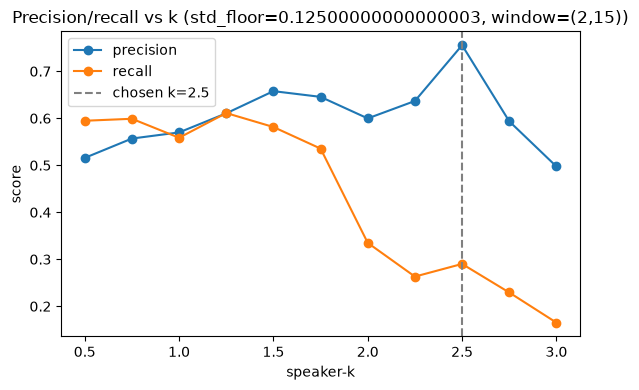

In [43]:
import matplotlib.pyplot as plt

ks = sorted(set(gp.k for gp in results))
precisions, recalls = [], []
for k in ks:
    gp = evaluate_params(train_sessions, embeddings_by_session,
                          k, best_val.std_floor, best_val.min_window, best_val.max_window,
                          min_active_seconds=best_val.min_active_seconds,
                          beta=BETA, include_gap_zero=False)
    precisions.append(gp.mean_precision)
    recalls.append(gp.mean_recall)

plt.figure(figsize=(6, 4))
plt.plot(ks, precisions, marker="o", label="precision")
plt.plot(ks, recalls, marker="o", label="recall")
plt.axvline(best_val.k, color="gray", linestyle="--", label=f"chosen k={best_val.k}")
plt.xlabel("speaker-k")
plt.ylabel("score")
plt.title(f"Precision/recall vs k (std_floor={best_val.std_floor}, "
          f"window=({best_val.min_window},{best_val.max_window}))")
plt.legend()
plt.tight_layout()
plt.show()
